In [20]:
import torch 
import torch.nn as nn 
import math 
import torch.nn.functional as F

# Requirements
According to attention is all you need , we require the following things
1) scaled-dot product function 
2) positional encoding
3) multihead attention class
4) normalization layer
5) feed forward layer


In [21]:
def scaled_dot_product(q , k , v):
    d_k = q.size()[-1] #dimension of queries = dimension of keys
    #here q k have dimesions --> (batch_size , sequence_length , dimension) , with .T(-1,-2) last two dimenstions are flipped
    scaled_dot = torch.matmul(q , k.transpose(-2 ,- 1)) / math.sqrt(d_k)       
    attention = F.softmax(scaled_dot , dim = -1)
    values = torch.matmul(attention , v) 
    return values , attention 

In [22]:
class positional_encoding(nn.Module):
    def __init__(self, d_model , seq_len , dropout = 0.3):
        super().__init__()
        #LLM used for help with syntax
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(seq_len , d_model)   # seq_len x d_model   
        position = torch.arange(0 , seq_len).unsqueeze(1).float() # seq_len x 1
        factor = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[: , 0::2] = torch.sin(position*factor) #assigning position encoding of sin function at even indices
        pe[: , 1::2] = torch.cos(position*factor) # assigning position encoding of cos function at odd indices
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_seq_len, d_model)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [77]:
class MultiheadAttention(nn.Module):
    def __init__(self, d_model , num_heads):
        super().__init__()
        self.d_model = d_model 
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads  #in the original document the number of heads were 8 so we had dimension of 
        #each head as 512 / 8 = 64 
        #so we have 8 parallel layers after projecting original in 8 diff dimensions working on different part of input.
        self.qkv = nn.Linear(d_model , 3*d_model)  #we have stacked q k and v matrices therefore 3 times the dimension of head (for each head)
        self.linear = nn.Linear(d_model , d_model)

    def forward( self , x):
        
        batch_size , seq_len , d_model= x.size() #batch_size we get from the dataloader
        qkv = self.qkv(x)
        qkv = qkv.reshape(batch_size , seq_len , self.num_heads , 3*self.head_dim) 
        #if the dimension initially was 256(batch) x 10 x 3*d_model , now the dimension is 256 x 10 x 8 x 192
        qkv = qkv.permute(0,2,1,3) # dimension is 256 x 8 x 10 x 192 (all q k and v layers are stacked)
        # next step is to separate these layers into 3 so that they can be passed through scaled_dot fxn
        q,k,v = qkv.chunk(3 , dim = -1) #separated wrt last dimension 
        values , attention = scaled_dot_product(q ,k ,v)
        values = values.reshape(batch_size , seq_len , self.num_heads * self.head_dim)
        result = self.linear(values)
        return result , attention

In [24]:
class feedforward(nn.Module):
    #creating a basic feed forward layer and forward pass function for it 
    
    def __init__(self, d_model, d_ff , dropout = 0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(d_model , d_ff),
            nn.ReLU(),
            nn.Dropout(dropout), # applying dropi=out for regularization of weights
            nn.Linear(d_ff , d_model)
        )
    def forward(self ,x):
        return self.layers(x)

In [78]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_head, d_ff , dropout = 0.3):
        super().__init__()
        self.attention = MultiheadAttention(d_model , num_head)
        self.fflayer = feedforward(d_model , d_ff , dropout)
        self.norm = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    # Made on the basis of attention is all you need research paper

    def forward(self, x):  
                                
        rem_x = x
        x , attention = self.attention(x) 
        x = self.dropout(x)
        #Multihead attention layer , then normalization on output and residual 
        x = self.norm(rem_x + x)
        rem_x = x
        x = self.fflayer(x)
        #Feed Forward layer , then normalization on output and residual 
        x = self.dropout2(x)
        x = self.norm2(rem_x + x)
        return x , attention

In [80]:
class Encoder(nn.Module):
    def __init__(self , d_model , seq_len , d_ff , num_head , num_layers , dropout = 0.3):
        super().__init__()
        self.input_proj = nn.Linear(1,d_model)
        self.pos_encoding = positional_encoding(d_model , seq_len , dropout)
        self.layers = nn.Sequential(*[EncoderLayer(d_model , num_head , d_ff , dropout)
                                    for i in range(num_layers)])
        self.final = nn.Linear(d_model , 10)
    def forward(self,x):
        attention_weights = []
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x , attn = layer(x)
            attention_weights.append(attn)
        x = self.final(x)
        self.attention_weights = attention_weights
        return x

In [81]:
# Encoder layer without positional encoding
class EncoderWPE(nn.Module):
    def __init__(self , d_model , seq_len , d_ff , num_head , num_layers , dropout = 0.3):
        super().__init__()
        self.input_proj = nn.Linear(1,d_model)
        # self.pos_encoding = positional_encoding(d_model , seq_len , dropout)
        self.layers = nn.Sequential(*[EncoderLayer(d_model , num_head , d_ff , dropout)
                                    for i in range(num_layers)])
        self.final = nn.Linear(d_model , 10)
    def forward(self,x):
        x = self.input_proj(x)
        # x = self.pos_encoding(x)
        x = self.layers(x)
        x = self.final(x)
        return x

In [82]:
# Done with the main structure of the encoder 

In [83]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [84]:
df = pd.read_csv("ranking_dataset.csv")
val = df.iloc[: , :10]
rank = df.iloc[: , 10:]
val = val.to_numpy()
rank = rank.to_numpy()

In [85]:
def train_encoder( d_model ,seq_len ,  d_ff , num_head , num_layers, train_data , val_data , epochs = 20):
    model = Encoder(d_model ,seq_len , d_ff , num_head , num_layers)
    device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    #LLM used for fixing some erros regarding the dimensions
    optimizer = torch.optim.Adam(model.parameters() , lr = 1e-4)
    lossfxn = nn.CrossEntropyLoss()
    loss_train = []
    loss_val = []
    for epoch in range(epochs):
        model.train() #to switch the model for training purpose
        total_loss = 0
        for val , rank in train_data:
            optimizer.zero_grad()
            val , rank = torch.tensor(val) , torch.tensor(rank)
            val ,rank = val.to(device) , rank.to(device)
            val_input = val.float().unsqueeze(-1)
            output = model(val_input)
            loss = lossfxn(output.permute(0,2,1) , rank.long()) #LLM used for dimension matching 
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        loss_train.append(total_loss) 
        model.eval() #to switch the model in evaluating mode
        with torch.no_grad():
            total_loss = 0
            for val ,rank in val_data:
                val , rank = torch.tensor(val) , torch.tensor(rank)
                val ,rank = val.to(device) , rank.to(device)
                output = model(val.float().unsqueeze(-1))
                loss = lossfxn(output.permute(0,2,1) , rank.long())
                total_loss+=loss.item()
            loss_val.append(total_loss)
        print(f"Epoch : {epoch+1} Training Loss: {loss_train[epoch]:.2f} Validation Loss: {loss_val[epoch]:.2f}")

    return model , loss_train , loss_val 

In [86]:
def train_encoder_woposi( d_model ,seq_len ,  d_ff , num_head , num_layers, train_data , val_data , epochs = 20):
    model = EncoderWPE(d_model ,seq_len , d_ff , num_head , num_layers)
    device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    #LLM used for fixing some erros regarding the dimensions
    optimizer = torch.optim.Adam(model.parameters() , lr = 1e-4)
    lossfxn = nn.CrossEntropyLoss()
    loss_train = []
    loss_val = []
    for epoch in range(epochs):
        model.train() #to switch the model for training purpose
        total_loss = 0
        for val , rank in train_data:
            optimizer.zero_grad()
            val , rank = torch.tensor(val) , torch.tensor(rank)
            val ,rank = val.to(device) , rank.to(device)
            val_input = val.float().unsqueeze(-1)
            output = model(val_input)
            loss = lossfxn(output.permute(0,2,1) , rank.long()) #LLM used for dimension matching 
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        loss_train.append(total_loss) 
        model.eval() #to switch the model in evaluating mode
        with torch.no_grad():
            total_loss = 0
            for val ,rank in val_data:
                val , rank = torch.tensor(val) , torch.tensor(rank)
                val ,rank = val.to(device) , rank.to(device)
                output = model(val.float().unsqueeze(-1))
                loss = lossfxn(output.permute(0,2,1) , rank.long())
                total_loss+=loss.item()
            loss_val.append(total_loss)
        print(f"Epoch : {epoch+1} Training Loss: {loss_train[epoch]:.2f} Validation Loss: {loss_val[epoch]:.2f}")

    return model , loss_train , loss_val 

In [87]:
# Creating dataset for training and validation data using dataset and dataloader

In [88]:
from torch.utils.data import Dataset, DataLoader
class Data(Dataset):
    def __init__(self , val , rank ):
        self.val = torch.tensor(val)
        self.rank = torch.tensor(rank)
    def __len__(self):
        return len(self.val)
    def __getitem__(self , idx):
        return self.val[idx] , self.rank[idx]

In [89]:
train_data = DataLoader(Data(val,rank) , batch_size = 512 , shuffle =True)
val_data = DataLoader(Data(val,rank) , batch_size = 128)

In [135]:
#initializing model parameters
d_model = 1024
seq_len = val.shape[1]
d_ff = 4096
num_head = 8
num_layers = 4
epochs = 30

In [136]:
print(val.shape[1])

10


In [137]:
model , loss_train , loss_val = train_encoder(d_model , seq_len , d_ff , num_head , num_layers, train_data , val_data , epochs = epochs)


C:\Users\divya\AppData\Local\Temp\ipykernel_20696\3837193365.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)
C:\Users\divya\AppData\Local\Temp\ipykernel_20696\3837193365.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)


Epoch : 1 Training Loss: 41.90 Validation Loss: 168.17
Epoch : 2 Training Loss: 32.10 Validation Loss: 112.61
Epoch : 3 Training Loss: 26.71 Validation Loss: 90.85
Epoch : 4 Training Loss: 23.08 Validation Loss: 81.59
Epoch : 5 Training Loss: 21.48 Validation Loss: 78.06
Epoch : 6 Training Loss: 21.12 Validation Loss: 74.42
Epoch : 7 Training Loss: 21.05 Validation Loss: 73.06
Epoch : 8 Training Loss: 19.28 Validation Loss: 65.49
Epoch : 9 Training Loss: 18.43 Validation Loss: 63.75
Epoch : 10 Training Loss: 17.98 Validation Loss: 59.72
Epoch : 11 Training Loss: 17.63 Validation Loss: 59.59
Epoch : 12 Training Loss: 17.00 Validation Loss: 61.60
Epoch : 13 Training Loss: 16.52 Validation Loss: 58.19
Epoch : 14 Training Loss: 16.56 Validation Loss: 58.00
Epoch : 15 Training Loss: 16.52 Validation Loss: 55.40
Epoch : 16 Training Loss: 16.02 Validation Loss: 54.30
Epoch : 17 Training Loss: 15.48 Validation Loss: 53.95
Epoch : 18 Training Loss: 15.49 Validation Loss: 50.40
Epoch : 19 Traini

In [138]:
#function for predicting
def predict(model, X):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad(): 
        X_tensor = torch.tensor(X).float().unsqueeze(-1)
        X_tensor = X_tensor.to(device)
        predictions = model(X_tensor)
        rankings = torch.argmax(predictions , dim = 2)
        rankings = rankings.cpu()
    return rankings.numpy()

In [139]:
#function for checking accuracy using token wise accuracy metric
def token_level_acc(pred , true):
    n = len(pred[0])
    sum = 0 
    for i in range(len(pred)):
        total = 0
        for j in range(n):
            if pred[i][j] == true[i][j]:
                total+=1
        percentage = total/n
        sum+=percentage
    return (sum/len(pred))*100


In [140]:
#creating the testing dataset
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    val,
    rank,
    test_size = 0.1,
    random_state= 42
)

In [141]:
predictions = predict(model , X_test)

In [142]:
print(predictions[1])
print(y_test[1])
print(X_test[1])


print(token_level_acc(predictions , y_test))

[8 7 1 0 3 5 6 3 8 5]
[9 7 1 0 2 4 6 3 8 5]
[921 870  64  27  98 301 580 113 870 302]
67.8600000000001


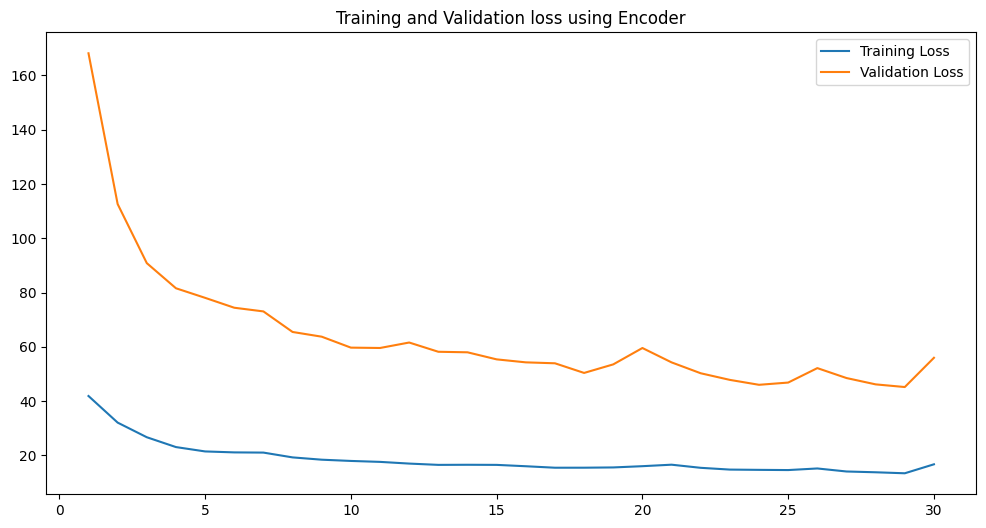

In [143]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize = (12,6))
x = np.arange(1 , epochs+1)
plt.plot(x , loss_train , label = "Training Loss")
plt.plot(x , loss_val , label = "Validation Loss")
plt.title("Training and Validation loss using Encoder")
plt.legend()
plt.savefig("T&VLossEnc.png")
plt.show()

In [144]:
#Out-Of-Distribution training
model_seq = [
    [1,2,3,4,5,6,7,8,9,10],
    [5,5,5,5,5,5,5,5,5,5],
    [1000,900,800,700,600,500,400,300,200,100],
    [20,40,60,80,100,120,140,160,180,200],
    [4000,6000,2000,1000,10000,8500,15000,20000,17500,500]
]
pred = predict(model , model_seq)
print(pred)

[[0 1 2 3 4 6 6 7 8 9]
 [8 8 8 8 8 8 0 0 8 0]
 [8 8 7 7 5 4 3 2 1 0]
 [0 1 2 3 4 6 6 7 8 9]
 [3 4 2 1 6 6 7 8 8 0]]


In [146]:
model_seq_pred = [
    [0,1,2,3,4,5,6,7,8,9],
    [0,0,0,0,0,0,0,0,0,0],
    [9,8,7,6,5,4,3,2,1,0],
    [0,1,2,3,4,5,6,7,8,9],
    [3,4,2,1,6,5,7,9,8,0],
]
print(token_level_acc(pred , model_seq_pred))

74.0


# Applying sequence normalization 

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

val_scaled = scaler_X.fit_transform(val)
train_scaled_data = DataLoader(Data(val_scaled,rank) , batch_size = 512 , shuffle =True)
val_scaled_data = DataLoader(Data(val_scaled,rank) , batch_size = 128)
model2 ,loss_train2 , loss_val2 = train_encoder(d_model , seq_len , d_ff , num_head , num_layers, train_scaled_data , val_scaled_data , epochs = epochs)


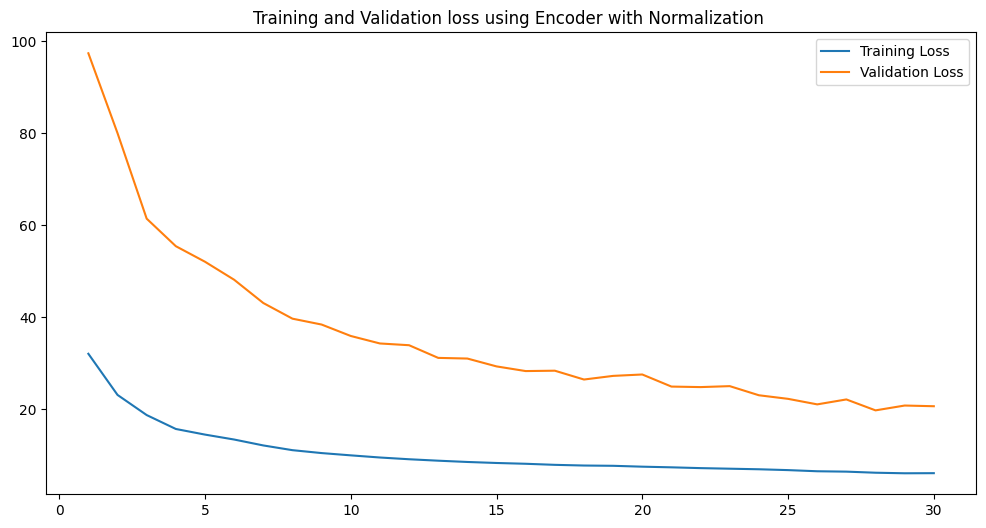

In [ ]:
plt.figure(figsize = (12,6))
x = np.arange(1 , epochs+1)
plt.plot(x , loss_train2 , label = "Training Loss")
plt.plot(x , loss_val2 , label = "Validation Loss")
plt.title("Training and Validation loss using Encoder with Normalization ")
plt.legend()
plt.savefig("T&VLossEncN.png")
plt.show()

In [ ]:
# Prediction on the basis of normalized data 
pred_norm = predict(model2 , X_test)

In [ ]:
print(token_level_acc(pred_norm , y_test))
i=5
print(pred_norm[i])
print(y_test[i])

21.799999999999844
[5 0 0 8 0 8 0 3 0 8]
[4 5 3 8 1 2 6 7 0 9]


In [62]:
#testing on out of distribution dataset 
pred_ood = predict(model2 , model_seq)
print(pred_ood)
print(model_seq)

[[0 2 2 5 4 8 7 7 7 7]
 [5 3 5 6 4 8 6 6 3 2]
 [8 8 8 8 4 8 0 0 0 0]
 [0 0 0 5 5 8 8 8 8 8]
 [0 0 0 6 3 8 8 8 8 0]]
[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [5, 5, 5, 5, 5, 5, 5, 5, 5, 5], [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100], [20, 40, 60, 80, 100, 120, 140, 160, 180, 200], [4000, 6000, 2000, 1000, 10000, 8500, 15000, 20000, 17500, 500]]


# Encoder without positional encoding

In [66]:
model2 , loss_train2 , loss_val2 = train_encoder_woposi(d_model , seq_len , d_ff , num_head , num_layers, train_data , val_data , epochs = epochs)


C:\Users\divya\AppData\Local\Temp\ipykernel_20696\2081479442.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)
C:\Users\divya\AppData\Local\Temp\ipykernel_20696\2081479442.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)


Epoch : 1 Training Loss: 40.19 Validation Loss: 135.24
Epoch : 2 Training Loss: 31.69 Validation Loss: 114.78
Epoch : 3 Training Loss: 27.35 Validation Loss: 100.24
Epoch : 4 Training Loss: 24.68 Validation Loss: 98.13
Epoch : 5 Training Loss: 23.00 Validation Loss: 86.21
Epoch : 6 Training Loss: 21.57 Validation Loss: 85.58
Epoch : 7 Training Loss: 20.36 Validation Loss: 82.69
Epoch : 8 Training Loss: 19.55 Validation Loss: 78.50
Epoch : 9 Training Loss: 18.88 Validation Loss: 80.24
Epoch : 10 Training Loss: 18.19 Validation Loss: 72.79
Epoch : 11 Training Loss: 17.72 Validation Loss: 79.54
Epoch : 12 Training Loss: 17.19 Validation Loss: 78.36
Epoch : 13 Training Loss: 16.87 Validation Loss: 75.56
Epoch : 14 Training Loss: 16.49 Validation Loss: 71.51
Epoch : 15 Training Loss: 16.20 Validation Loss: 74.59
Epoch : 16 Training Loss: 15.84 Validation Loss: 76.95
Epoch : 17 Training Loss: 15.65 Validation Loss: 71.79
Epoch : 18 Training Loss: 15.39 Validation Loss: 77.98
Epoch : 19 Train

In [67]:
predictions2 = predict(model2 , X_test)
print(token_level_acc(predictions2 , y_test))

63.12000000000014


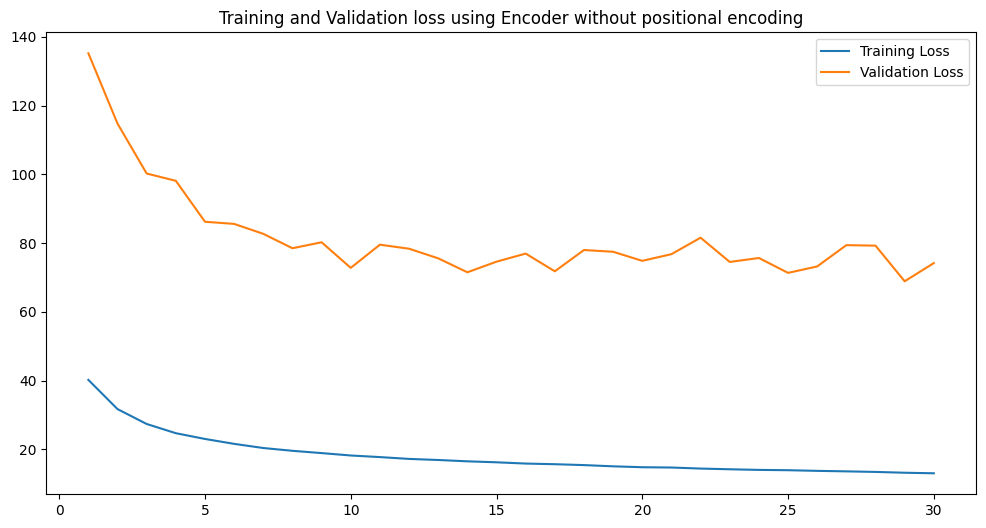

In [68]:
plt.figure(figsize = (12,6))
x = np.arange(1 , epochs+1)
plt.plot(x , loss_train2 , label = "Training Loss")
plt.plot(x , loss_val2 , label = "Validation Loss")
plt.title("Training and Validation loss using Encoder without positional encoding")
plt.legend()
plt.savefig("T&VLossEncWPE.png")
plt.show()

# Layer comparision between encoders

In [69]:
#initializing model parameters
d_model = 512
seq_len = val.shape[1]
d_ff = 2048
num_head = 8
num_layers1 = 1
num_layers2=2
num_layers4 = 4
epochs = 30

In [70]:
model_l1 , loss_train_l1 , loss_val_l1 = train_encoder(d_model , seq_len , d_ff , num_head , num_layers1 , train_data , val_data , epochs = epochs)


C:\Users\divya\AppData\Local\Temp\ipykernel_20696\1074828264.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)
C:\Users\divya\AppData\Local\Temp\ipykernel_20696\1074828264.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)


Epoch : 1 Training Loss: 42.74 Validation Loss: 154.59
Epoch : 2 Training Loss: 37.77 Validation Loss: 142.15
Epoch : 3 Training Loss: 36.07 Validation Loss: 137.74
Epoch : 4 Training Loss: 35.01 Validation Loss: 132.83
Epoch : 5 Training Loss: 34.05 Validation Loss: 129.39
Epoch : 6 Training Loss: 33.44 Validation Loss: 128.36
Epoch : 7 Training Loss: 32.94 Validation Loss: 126.01
Epoch : 8 Training Loss: 32.63 Validation Loss: 124.99
Epoch : 9 Training Loss: 32.43 Validation Loss: 124.63
Epoch : 10 Training Loss: 32.30 Validation Loss: 123.58
Epoch : 11 Training Loss: 32.17 Validation Loss: 124.10
Epoch : 12 Training Loss: 32.06 Validation Loss: 123.55
Epoch : 13 Training Loss: 31.98 Validation Loss: 122.93
Epoch : 14 Training Loss: 31.91 Validation Loss: 122.54
Epoch : 15 Training Loss: 31.84 Validation Loss: 123.39
Epoch : 16 Training Loss: 31.74 Validation Loss: 123.25
Epoch : 17 Training Loss: 31.67 Validation Loss: 122.27
Epoch : 18 Training Loss: 31.69 Validation Loss: 122.40
E

In [71]:
model_l2 , loss_train_l2 , loss_val_l2 = train_encoder(d_model , seq_len , d_ff , num_head , num_layers2 , train_data , val_data , epochs = epochs)


C:\Users\divya\AppData\Local\Temp\ipykernel_20696\1074828264.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)
C:\Users\divya\AppData\Local\Temp\ipykernel_20696\1074828264.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)


Epoch : 1 Training Loss: 42.28 Validation Loss: 145.92
Epoch : 2 Training Loss: 36.15 Validation Loss: 133.98
Epoch : 3 Training Loss: 33.02 Validation Loss: 117.61
Epoch : 4 Training Loss: 29.89 Validation Loss: 109.98
Epoch : 5 Training Loss: 28.10 Validation Loss: 101.98
Epoch : 6 Training Loss: 26.95 Validation Loss: 98.56
Epoch : 7 Training Loss: 26.15 Validation Loss: 95.51
Epoch : 8 Training Loss: 25.52 Validation Loss: 93.60
Epoch : 9 Training Loss: 25.29 Validation Loss: 95.96
Epoch : 10 Training Loss: 24.92 Validation Loss: 91.04
Epoch : 11 Training Loss: 24.52 Validation Loss: 92.25
Epoch : 12 Training Loss: 24.28 Validation Loss: 88.52
Epoch : 13 Training Loss: 23.97 Validation Loss: 88.93
Epoch : 14 Training Loss: 23.74 Validation Loss: 87.17
Epoch : 15 Training Loss: 23.49 Validation Loss: 86.57
Epoch : 16 Training Loss: 23.32 Validation Loss: 85.00
Epoch : 17 Training Loss: 23.11 Validation Loss: 85.63
Epoch : 18 Training Loss: 22.81 Validation Loss: 84.11
Epoch : 19 Tra

In [72]:
model_l4 , loss_train_l4 , loss_val_l4 = train_encoder(d_model , seq_len , d_ff , num_head , num_layers4 , train_data , val_data , epochs = epochs)


C:\Users\divya\AppData\Local\Temp\ipykernel_20696\1074828264.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)
C:\Users\divya\AppData\Local\Temp\ipykernel_20696\1074828264.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val , rank = torch.tensor(val) , torch.tensor(rank)


Epoch : 1 Training Loss: 42.09 Validation Loss: 143.46
Epoch : 2 Training Loss: 36.13 Validation Loss: 129.85
Epoch : 3 Training Loss: 31.43 Validation Loss: 109.72
Epoch : 4 Training Loss: 27.78 Validation Loss: 97.59
Epoch : 5 Training Loss: 25.53 Validation Loss: 90.00
Epoch : 6 Training Loss: 23.88 Validation Loss: 86.43
Epoch : 7 Training Loss: 22.88 Validation Loss: 80.47
Epoch : 8 Training Loss: 22.13 Validation Loss: 78.80
Epoch : 9 Training Loss: 21.38 Validation Loss: 84.44
Epoch : 10 Training Loss: 21.02 Validation Loss: 78.37
Epoch : 11 Training Loss: 20.57 Validation Loss: 318.79
Epoch : 12 Training Loss: 35.46 Validation Loss: 100.19
Epoch : 13 Training Loss: 24.13 Validation Loss: 81.90
Epoch : 14 Training Loss: 21.36 Validation Loss: 73.72
Epoch : 15 Training Loss: 20.25 Validation Loss: 70.40
Epoch : 16 Training Loss: 19.41 Validation Loss: 67.03
Epoch : 17 Training Loss: 18.97 Validation Loss: 64.81
Epoch : 18 Training Loss: 18.42 Validation Loss: 64.91
Epoch : 19 Tra

In [73]:
predictions_l1 = predict(model_l1 , X_test)
print(f"TWA for 1 layers {token_level_acc(predictions_l1 , y_test):.2f}")
predictions_l2 = predict(model_l2 , X_test)
print(f"TWA for 2 layers {token_level_acc(predictions_l2 , y_test):.2f}")
predictions_l4 = predict(model_l4 , X_test)
print(f"TWA for 4 layers {token_level_acc(predictions_l4 , y_test):.2f}")

TWA for 1 layers 39.81
TWA for 2 layers 55.88
TWA for 4 layers 68.92


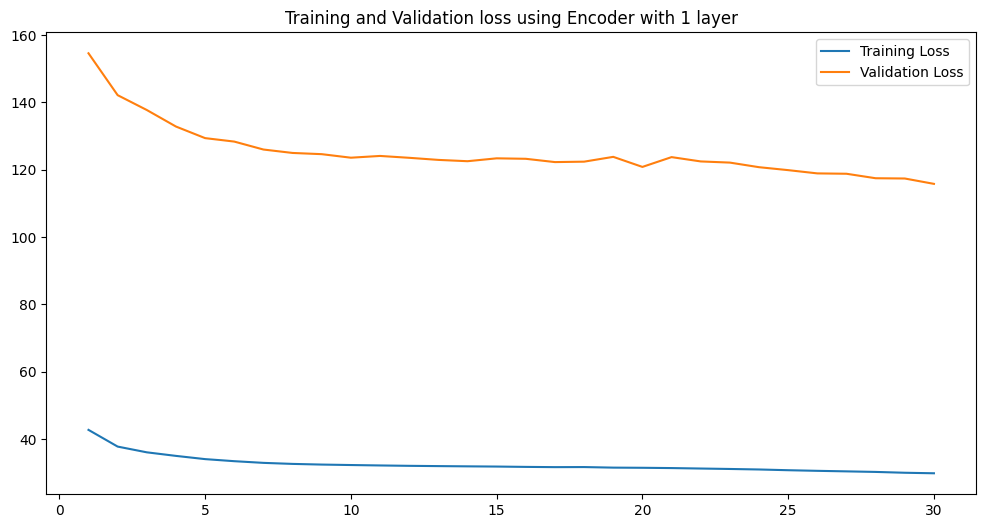

In [74]:
plt.figure(figsize = (12,6))
x = np.arange(1 , epochs+1)
plt.plot(x , loss_train_l1 ,  label = "Training Loss")
plt.plot(x , loss_val_l1 , label = "Validation Loss")
plt.title("Training and Validation loss using Encoder with 1 layer")
plt.legend()
plt.savefig("T&VLossEnc1L.png")
plt.show()

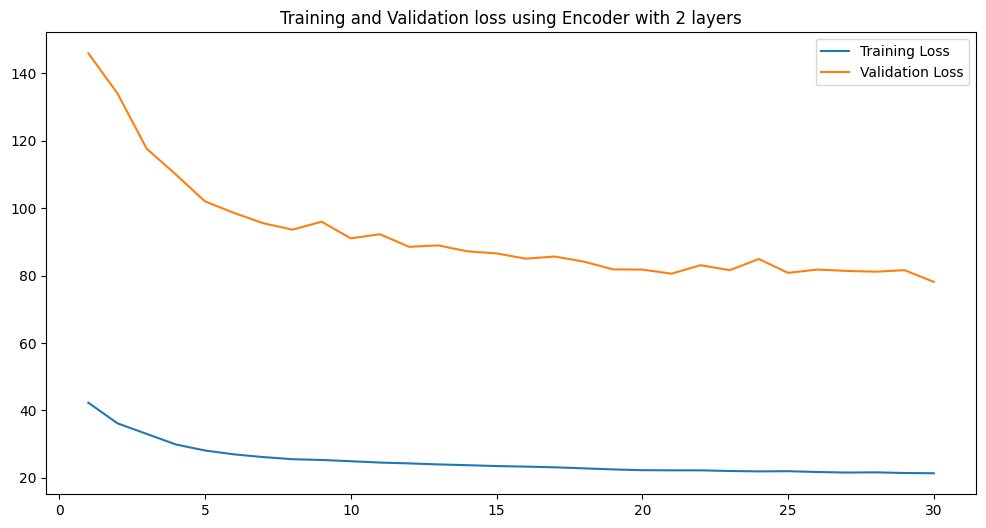

In [75]:
plt.figure(figsize = (12,6))
x = np.arange(1 , epochs+1)
plt.plot(x , loss_train_l2 , label = "Training Loss")
plt.plot(x , loss_val_l2 , label = "Validation Loss")
plt.title("Training and Validation loss using Encoder with 2 layers")
plt.legend()
plt.savefig("T&VLossEnc2L.png")
plt.show()

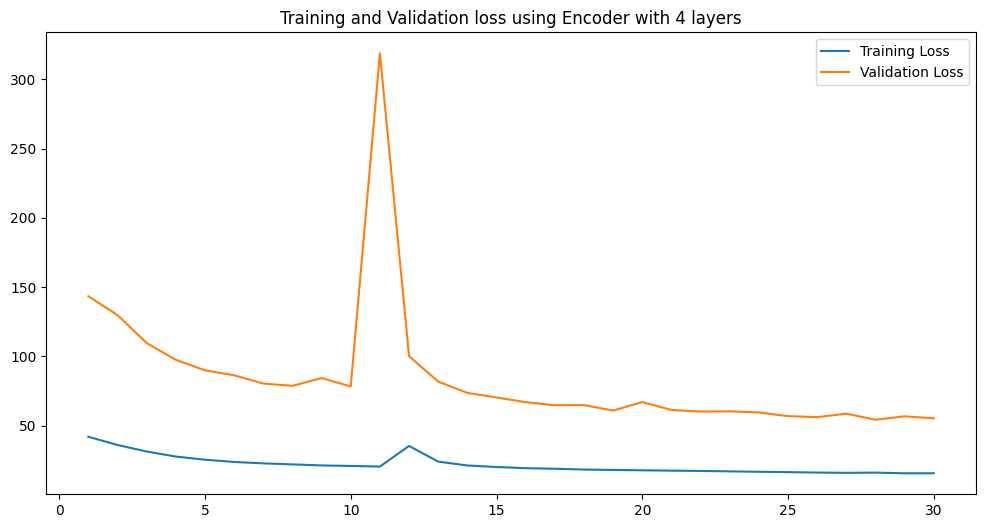

In [76]:
plt.figure(figsize = (12,6))
x = np.arange(1 , epochs+1)
plt.plot(x , loss_train_l4 , label = "Training Loss")
plt.plot(x , loss_val_l4 , label = "Validation Loss")
plt.title("Training and Validation loss using Encoder with 4 layers")
plt.legend()
plt.savefig("T&VLossEnc4L.png")
plt.show()